<br>
<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://uvv.br/wp-content/themes/core/dist/images/Logo@2x.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>ANÁLISE EXPLORATÓRIA DOS DADOS</b></CENTER>
        <CENTER><b>ANÁLISE AMOSTRA - UNDERSAMPLINGL</b></CENTER>
        </font>
  </body>
</html>

**NOME:** Isabela Carone Lacerda

**LINK PARA ESTE NOTEBOOK:** [Aqui!]()

# BIBLIOTECAS E FUNÇÕES

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os

In [ ]:
def statistic(_dataset):
    """
      Compute descriptive statistics for a numerical dataset.

      This function extends the standard pandas `describe()` method
      by removing the count metric and adding:
      - Range (max - min)
      - Mode

      The output is a table of descriptive statistics commonly used
      in Exploratory Data Analysis (EDA).

      Parameters
      ----------
      _dataset : pandas.Series or pandas.DataFrame
          Input dataset containing numerical values.

      Returns
      -------
      pandas.DataFrame
          A DataFrame with descriptive statistics (excluding count),
          including range and mode, sorted and rounded to two decimals.
    """

    # Generate basic descriptive statistics using pandas
    # (count, mean, std, min, quartiles, and max)
    _describe = _dataset.describe()

    # Remove the 'count' row, as it is not used in this analysis
    _describe = _describe.drop('count')

    # Compute the range for each numerical column
    # Range = maximum value minus minimum value
    _describe.loc['range'] = _describe.loc['max'] - _describe.loc['min']

    # Compute the mode for each numerical column
    # stats.mode returns both mode and frequency;
    # [0] extracts only the modal value
    _describe.loc['mode'] = stats.mode(
        _dataset,
        keepdims=False,
        nan_policy='omit'
    )[0]

    # Sort the statistics (index) and round all values to two decimal places
    _describe = np.around(_describe.sort_values(), 2)

    # Return the final descriptive statistics table
    return _describe

In [ ]:
def PlotarStatistic(dataset, yLabel=None):
    """
      Plot descriptive statistics of a dataset and highlight
      measures of central tendency (mean, median, and mode).

      This function computes descriptive statistics using a
      previously defined `statistic()` function, generates
      a plot with summary measures, and prints the numerical
      descriptive table.

      Parameters
      ----------
      dataset : pandas.Series or pandas.DataFrame
          Input dataset containing numerical values.
          It is expected that the statistic() function
          can process this object.

      yLabel : str, optional
          Label for the y-axis of the plot.

      Returns
      -------
      None
          Displays a plot and prints descriptive statistics.
    """

    # Compute descriptive statistics using a custom function
    _describe = statistic(dataset)

    # -------------------------------------------------------
    # Construction of LaTeX-formatted labels for statistics
    # -------------------------------------------------------

    # Mean (population notation: overline mu)
    # Raw string (r'') avoids invalid escape sequence warnings
    mean_mu = r'MÉDIA:  $\overline{\mu}$ = '
    mean_mu += f'{_describe["mean"]: .2f}'  # Numeric value formatted to 2 decimals

    # Median (tilde mu)
    median_mu = r'MEDIANA: $\tilde{\mu}$ = '
    median_mu += f'{_describe["50%"]: .2f}'

    # Mode (hat mu)
    mode_mu = r'MODA: $\hat{\mu}$ = '
    mode_mu += f'{_describe["mode"]: .2f}'

    # New line separator for legend text composition
    enter = '\n'

    # Concatenated label containing all summary measures
    label = mean_mu + enter + median_mu + enter + mode_mu

    # -------------------------------------------------------
    # Plotting section
    # -------------------------------------------------------

    # Apply the statistic function as an aggregation and plot the result
    # (Assumes dataset supports aggregation and plotting)
    dataset.agg(statistic).plot(
        figsize=[15, 6],
        label='MEDIDAS DE RESUMO: '
    )

    # Plot the mean marker at its corresponding index position
    plt.plot(
        list(_describe.index).index('mean'),
        _describe["mean"],
        'D',
        label=mean_mu
    )

    # Plot the median marker
    plt.plot(
        list(_describe.index).index('50%'),
        _describe["50%"],
        'D',
        label=median_mu
    )

    # Plot the mode marker
    plt.plot(
        list(_describe.index).index('mode'),
        _describe["mode"],
        'D',
        label=mode_mu
    )

    # Set plot title
    plt.title('ESTATÍSTICA DESCRITIVA DO DATASET')

    # Display legend with statistical labels
    plt.legend()

    # Set y-axis label if provided
    plt.ylabel(yLabel)

    # Render the plot
    plt.show()

    # -------------------------------------------------------
    # Textual output
    # -------------------------------------------------------

    # Print descriptive statistics table
    print('ESTATÍSTICA DESCRITIVA DO DATASET:')
    print(_describe)

##LOAD: SEU TABLE

In [ ]:
# LOAD DO DATASET
table = pd.read_csv('/content/table16.csv', index_col=0) # vira df aqui

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios'
print(os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['atividade3.ipynb', 'atividade2.ipynb', 'atividade2.html', 'atividade1.ipynb', 'atividade1.html']


In [ ]:
print(type(table))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
table.head()

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,6876333,SUL,MASCULINO,SOLTEIRO,1,3336.84,"Serviço eficiente, recomendo o clube: UVVine",68.680,12.929435,2.447630,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,5677339,SUDESTE,MASCULINO,CASADO,2,3453.34,"Serviço eficiente, recomendo o clube: UVVine",68.680,13.993214,1.393874,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,1104271,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,"Serviço impecável, adorei o clube: UVVine",68.680,11.161985,3.471322,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02
3,2691016,SUL,FEMININO,CASADO,1,26192.61,"Serviço eficiente, recomendo o clube: UVVine",77.972,13.361280,1.463516,...,1.991469,0.235816,0.607276,0.835639,3.284154,1.078509,1.955873,994.797550,PRIME,3930.88
4,6636530,CENTRO-OESTE,MASCULINO,SOLTEIRO,1,21792.17,Entrega foi boa e rápida na UVVine,68.680,13.536534,3.832572,...,2.269030,1.487258,0.222171,1.445279,4.178987,0.988953,1.591512,377.293171,PRIME,873.68


## FAZER AS QUESTÕES AQUI:

In [ ]:
def stratifiedAnalysis(
    table: pd.DataFrame,
    target: str,
    categoria: str
    ) -> pd.DataFrame:
    """
    Realiza a análise por estratificação amostral de uma variável quantitativa
    com base em uma variável qualitativa.

    A função calcula:
    - quantidade de elementos por estrato
    - média da variável target por estrato
    - tamanho da amostra balanceada (menor estrato)

    Args:
        table (pd.DataFrame): Dataset de entrada.
        target (str): Variável quantitativa.
        categoria (str): Variável qualitativa.

    Returns:
        pd.DataFrame: Tabela com contagem e média por estrato.
    """

    resumo = table.groupby(categoria)[target].agg(['count', 'mean']).sort_index()

    print('--- ANÁLISE POR ESTRATIFICAÇÃO AMOSTRAL ---')
    display(resumo)

    sample_size = resumo['count'].min()

    print(f'\nTamanho do sample usado: {sample_size}')
    print('Motivo: foi usado o tamanho do menor estrato para balancear a amostra entre os grupos.')

    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=resumo.index,
        y=resumo['mean'],
        hue=resumo.index,
        palette='Set2',
        legend=False
    )
    plt.title(f'Média de {target} por {categoria}', fontsize=14, fontweight='bold')
    plt.xlabel(categoria)
    plt.ylabel('Média')
    plt.show()

    return resumo

In [ ]:
def downSampling(
    table: pd.DataFrame,
    yLabel: str = None,
    Qualitativa: str = None
    ) -> pd.DataFrame:
    """
    Realiza o downsampling (undersampling) de um dataset com base
    em uma variável qualitativa, balanceando todas as classes
    pelo tamanho da menor classe.

    Args:
        table (pd.DataFrame): Dataset de entrada.
        yLabel (str): Variável quantitativa de interesse.
        Qualitativa (str): Variável qualitativa usada para balanceamento.

    Returns:
        pd.DataFrame: Dataset balanceado por undersampling.
    """

    if yLabel is None:
        raise ValueError("Informe a variável quantitativa em yLabel.")

    if Qualitativa is None:
        raise ValueError("Informe a variável qualitativa em Qualitativa.")

    if yLabel not in table.columns:
        raise ValueError(f"A coluna '{yLabel}' não existe no DataFrame.")

    if Qualitativa not in table.columns:
        raise ValueError(f"A coluna '{Qualitativa}' não existe no DataFrame.")

    classes = table[Qualitativa].value_counts()
    tamanho_amostra = classes.min()

    amostras = []

    for categoria in classes.index:
        subset = table[table[Qualitativa] == categoria]
        amostra = subset.sample(n=tamanho_amostra, random_state=42)
        amostras.append(amostra)

    table_balanceada = pd.concat(amostras, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

    print('--- TAMANHO ORIGINAL POR CLASSE ---')
    print(classes)
    print('\n--- TAMANHO USADO NO UNDERSAMPLING ---')
    print(tamanho_amostra)
    print('\n--- TAMANHO FINAL POR CLASSE ---')
    print(table_balanceada[Qualitativa].value_counts())

    return table_balanceada

#Questão 1:

Faça a análise por estratificação amostral da variável TARGET: y = TOTAL DE GASTOS (R$), por tipo:

*   ESSENTIAL
*   VIP
*   PRIME

sobre a métrica: Média (default)

Qual o TAMANHO do SAMPLE (amostra) USADO ? Motivo ?

--- ANÁLISE POR ESTRATIFICAÇÃO AMOSTRAL ---


,count,mean
TIPO DA CONTA,,
ESSENTIAL,666468,415.473952
PRIME,191799,2152.293346
VIP,261733,921.822841



Tamanho do sample usado: 191799
Motivo: foi usado o tamanho do menor estrato para balancear a amostra entre os grupos.


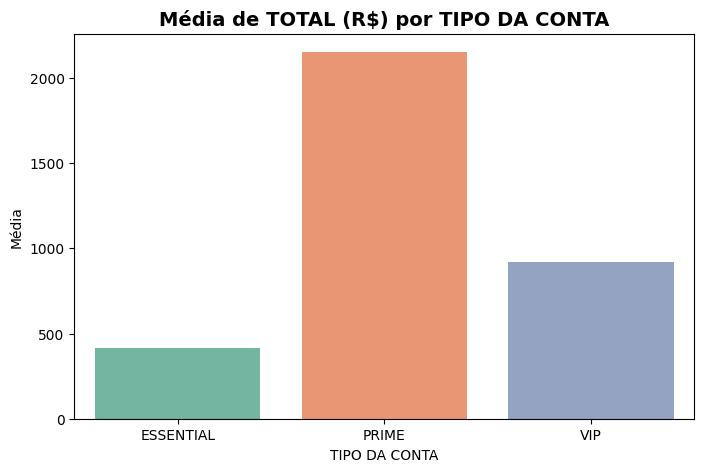

191799


In [ ]:
resumo_estratos = stratifiedAnalysis(
    table,
    target='TOTAL (R$)',
    categoria='TIPO DA CONTA'
)


sample_size = table['TIPO DA CONTA'].value_counts().min()
print(sample_size)

#Questão 2:

Faça uma função (**def + docstring**) que realize o downsampling de uma Variável Qualitativa TIPO DE CONTA.

Protótipo da função:

  * **def** downSampling(table, yLabel = None, Qualitativa = None)

Aplicar na coluna:
  
  * TOTAL DE GASTOS (R$)

In [ ]:
table_balanceada = downSampling(
    table,
    yLabel='TOTAL (R$)',
    Qualitativa='TIPO DA CONTA'
)

--- TAMANHO ORIGINAL POR CLASSE ---
TIPO DA CONTA
ESSENTIAL    666468
VIP          261733
PRIME        191799
Name: count, dtype: int64

--- TAMANHO USADO NO UNDERSAMPLING ---
191799

--- TAMANHO FINAL POR CLASSE ---
TIPO DA CONTA
ESSENTIAL    191799
PRIME        191799
VIP          191799
Name: count, dtype: int64


#Questão 3:

Reaplicar a função de análise: ESTATÍSTICA DESCRITIVA, após o undersampling:

  * SALÁRIO BRUTO (R$)
  
  * TOTAL DE GASTOS (R$)

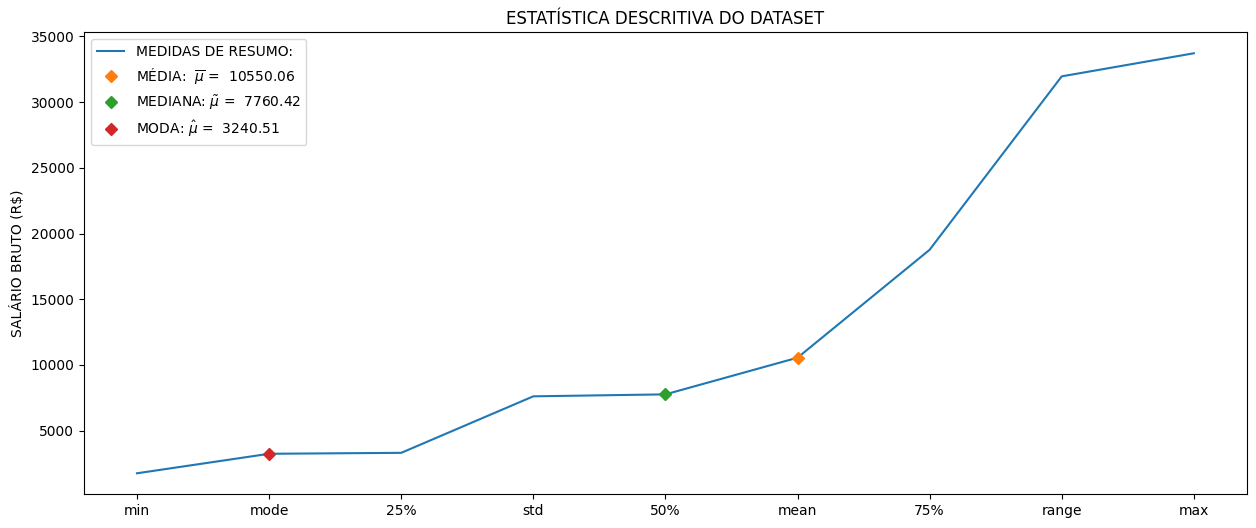

ESTATÍSTICA DESCRITIVA DO DATASET:
min       1756.31
mode      3240.51
25%       3311.25
std       7611.40
50%       7760.42
mean     10550.06
75%      18761.96
range    31957.74
max      33714.05
Name: RENDA BRUTO (R$), dtype: float64


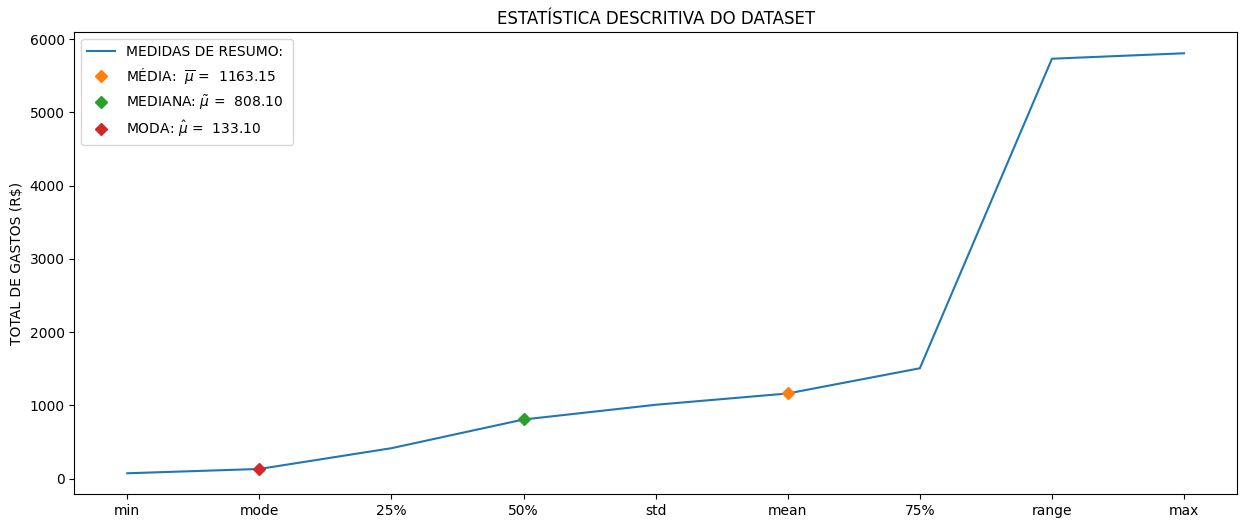

ESTATÍSTICA DESCRITIVA DO DATASET:
min        74.24
mode      133.10
25%       416.46
50%       808.10
std      1008.85
mean     1163.15
75%      1506.98
range    5730.58
max      5804.82
Name: TOTAL (R$), dtype: float64


In [ ]:
PlotarStatistic(
    table_balanceada['RENDA BRUTO (R$)'],
    yLabel='SALÁRIO BRUTO (R$)'
)
PlotarStatistic(
    table_balanceada['TOTAL (R$)'],
    yLabel='TOTAL DE GASTOS (R$)'
)

#CONCLUSÕES:

Pode-se chegar as seguintes conclusões:

* Conclusão 1


A análise por estratificação amostral da variável TOTAL (R$) mostrou que existe diferença entre as médias de gasto dos tipos de conta ESSENTIAL, VIP e PRIME, sendo possível comparar os grupos de forma organizada pela variável TIPO DA CONTA.



* Conclusão 2

O tamanho do sample utilizado no balanceamento foi o tamanho do menor estrato, 191799 observações, pois no undersampling todas as classes precisam ter a mesma quantidade de registros para evitar desequilíbrio entre os grupos.



* Conclusão 3


Após aplicar o downsampling, a análise estatística descritiva das variáveis RENDA BRUTO (R$) e TOTAL (R$) passa a ser feita sobre um conjunto balanceado, reduzindo o efeito da super-representação das classes maiores e tornando a comparação entre os tipos de conta mais adequada.


PARA ENTREGAR: Converter seu YPYNB para PDF:

In [ ]:
import os

path_exercicios = '/content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios'

nome_arquivo = 'atividade3.ipynb'
caminho_entrada = os.path.join(path_exercicios, nome_arquivo)

print(f"A converter: {nome_arquivo}")
print(f"Destino: {path_exercicios}")

!jupyter nbconvert --to html "{caminho_entrada}" --output-dir="{path_exercicios}"

print("\n✅ Concluído! O ficheiro HTML foi gerado diretamente na pasta do Drive.")

A converter: atividade3.ipynb
Destino: /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios
[NbConvertApp] Converting notebook /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios/atividade3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 486903 bytes to /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios/atividade3.html

✅ Concluído! O ficheiro HTML foi gerado diretamente na pasta do Drive.
